## Titanic - Train random forest with a GridSearchCV
> The titanic was sinking,
> the gigangic ship had hit an iceberg.
> Land war far, far away.

I Survived the Sinking of the Titanic, 1912 - Lauren Tarshis

### Description of the features

* Survived : (0 = No; 1 = Yes) 
* pclass : Passenger Class (1 = 1st; 2 = 2nd; 3 = 3rd) 
* sex : {'female': 1, 'male': 0}
* age : Passager age
* sibsp : Number of Siblings/Spouses Aboard 
* parch : Number of Parents/Children Aboard 
* ticket : Ticket Number 
* fare : Passenger Fare 
* cabin : Cabin 
* embarked : Port of Embarkation {'S': 0, 'C': 1, 'Q': 2}  (C = Cherbourg; Q = Queenstown; S = Southampton) 

### Importation of the libraries

In [1]:
# import
import pandas as pd
import numpy as np
import random as rnd
import os
import re

# visualization
import seaborn as sns
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
from sklearn.preprocessing import StandardScaler
%matplotlib inline
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score,precision_score, recall_score,f1_score

def print_metrics(y_train,y_pred):
    conf_mx = confusion_matrix(y_train,y_pred)
    print(conf_mx)
    print ("------------------------------------------")
    print (" Accuracy    : ", accuracy_score(y_train,y_pred))
    print (" Precision   : ", precision_score(y_train,y_pred))
    print (" Sensitivity : ", recall_score(y_train,y_pred))
    print ("------------------------------------------")

In [2]:
# load data
train_df = pd.read_csv('../input/train.csv')
test_df = pd.read_csv('../input/test.csv')
submit_df = pd.read_csv('../input/gender_submission.csv')
target = train_df["Survived"]

### Balance between survived people and not survived
Check if the dataset is unbalanced - and no, it is not.


In [3]:
print('_'*80)
print("Value counts in 'Survived' in train data (0 = No; 1 = Yes) : \n")
print(train_df["Survived"].value_counts())
print('_'*80)

________________________________________________________________________________
Value counts in 'Survived' in train data (0 = No; 1 = Yes) : 

0    549
1    342
Name: Survived, dtype: int64
________________________________________________________________________________


### Feature engineering

In [4]:
# Concat TEST and TRAIN data into df
###########################################
del train_df["Survived"]
train_df["Train"]=1
test_df["Train"]=0
df = pd.concat([train_df,test_df])
df.reset_index()


# Feature engineering
###########################################

# Ticket Count
temp = df['Ticket'].value_counts()
TicketCount = pd.DataFrame(temp.values,columns=['TicketCount'])
TicketCount['Ticket']=temp.index
df = pd.merge(df,TicketCount,on='Ticket', how='left')
df['TicketCount'].fillna(0)

# Name Length
df['NameLength'] = df['Name'].apply(lambda x : len(x))
df['NameLength'] = ((df.NameLength)/15).astype(np.int64)+1

# Ticket Letter
df['TicketLetter'] = df['Ticket'].apply(lambda x : str(x)[0]) 
df['TicketLetter'] = df['TicketLetter'].apply(lambda x : re.sub('[0-9]','N',x))
#df['TicketLetter'] = df['TicketLetter'].map({'A':0, 'W':1, 'L':2, 'S':3, 'C':4, 'N':5, 'F':6, 'P':7}).astype(int)

# Extract Title from Name
df['Title'] = df.Name.apply(lambda name: name.split(',')[1].split('.')[0].strip())
normalized_titles = {
    "Capt":       "Officer",
    "Col":        "Officer",
    "Major":      "Officer",
    "Jonkheer":   "Royalty",
    "Don":        "Royalty",
    "Sir" :       "Royalty",
    "Dr":         "Officer",
    "Rev":        "Officer",
    "the Countess":"Royalty",
    "Dona":       "Royalty",
    "Mme":        "Mrs",
    "Mlle":       "Miss",
    "Ms":         "Mrs",
    "Mr" :        "Mr",
    "Mrs" :       "Mrs",
    "Miss" :      "Miss",
    "Master" :    "Master",
    "Lady" :      "Royalty"
}
df['Title'] = df['Title'].map(normalized_titles)

# Family Size
df["FamilySize"] = df['SibSp'] + df['Parch'] + 1
bins = [-1,1, 2, 3,4, np.inf]
labels = ['ONE','TWO', 'THREE', 'FOUR','BIG']
df['FamilyGroup'] = pd.cut(df["FamilySize"], bins, labels = labels)

# Embarked
df["Embarked"] = df["Embarked"].fillna("S")

# Group By Age
df["Age"] = df.groupby(['Sex','Pclass','Title'])["Age"].transform(lambda x: x.fillna(x.median()))
bins = [-1, 14,20, 30, 50, np.inf]
labels = ['Child','Young','YoungAdult', 'Adult', 'Senior']
df['AgeGroup'] = pd.cut(df["Age"], bins, labels = labels)

# Letter of the cabin
df["Cabin"] = df["Cabin"].str[0:1]
df["Cabin"] = df["Cabin"].fillna('T')
#df['Cabin'] = df['Cabin'].map({'T':0, 'A':1, 'G':2, 'C':3, 'F':4, 'B':5, 'E':6, 'D':7}).astype(int)

# Group Fare
df['Fare'] = df['Fare'].fillna(-1)
bins = [-1,0,8, 32, 50, np.inf]
labels = ['Unknown','Low', 'Medium', 'High','Elite']
df['FareGroup'] = pd.cut(df["Fare"], bins, labels = labels)

# Filter Columns
filterCol = ['Pclass',  'Sex', 'AgeGroup', 'SibSp', 'Parch','FareGroup', 'Embarked','Title','Cabin', 'FamilyGroup','NameLength','TicketLetter','TicketCount']
# OneHotEncoder
df_f = pd.get_dummies(df[filterCol])
columns = df_f.columns

# split between train and test
features = df_f[df["Train"]==1].copy()
features_test = df_f[df["Train"]==0].copy()
# Original train data
train_df = pd.concat([df[df["Train"]==1].copy(),target],axis=1)

### Histograms of characteristics according to the survived property
Survived : 0 = No    1 = Yes

This is a visual exploration of the data - it is more likely to perish with these features :
* male
* age 

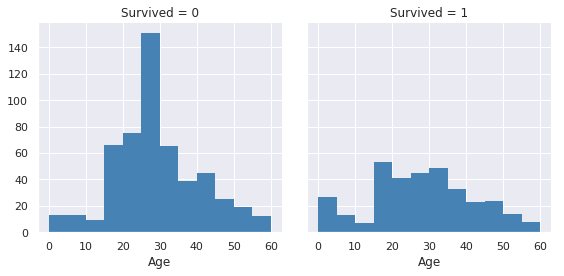

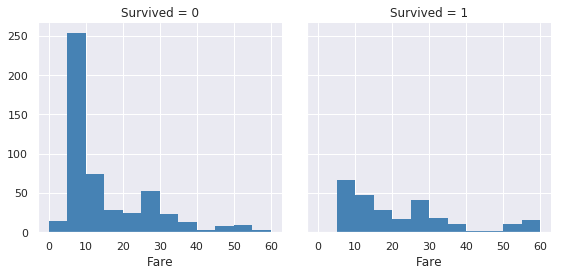

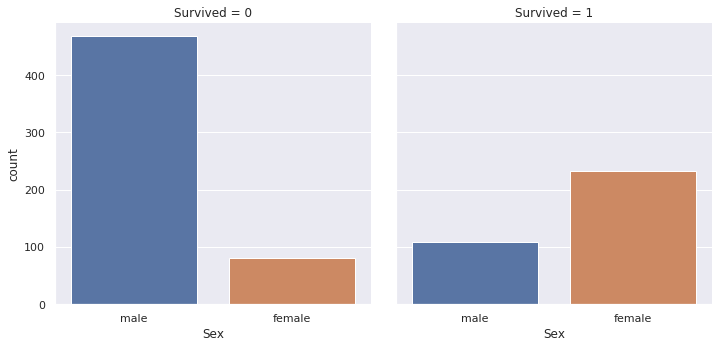

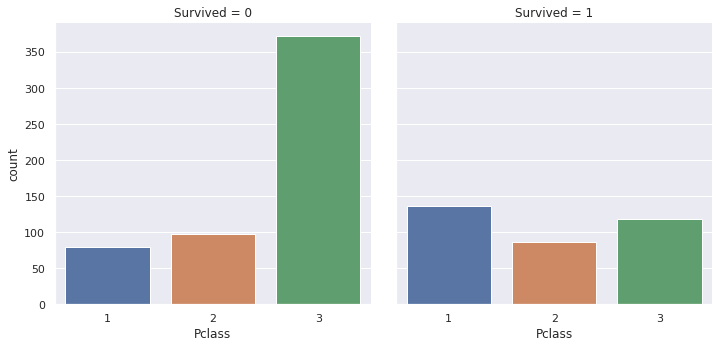

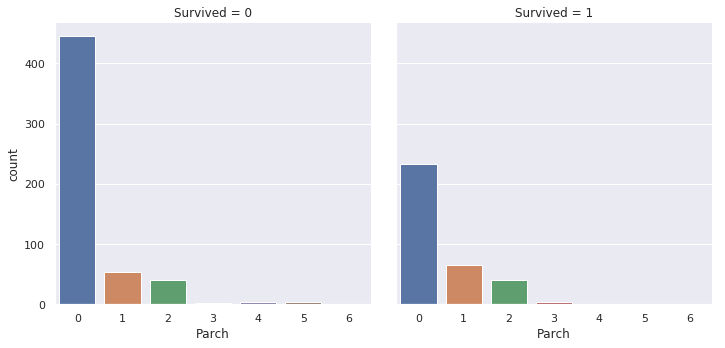

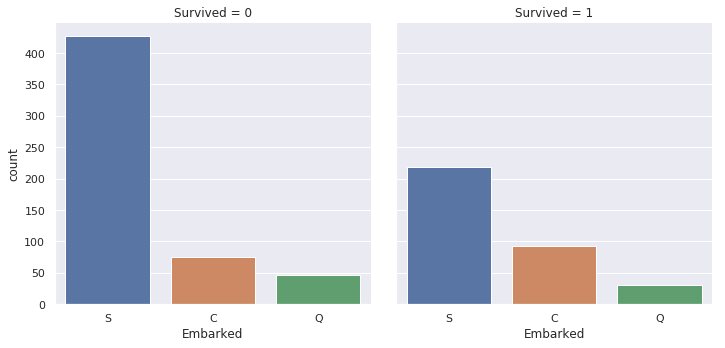

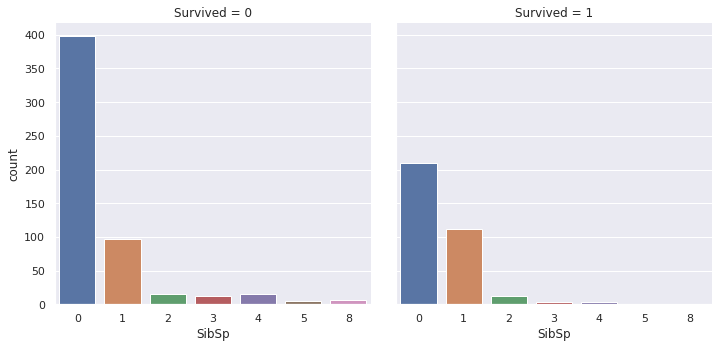

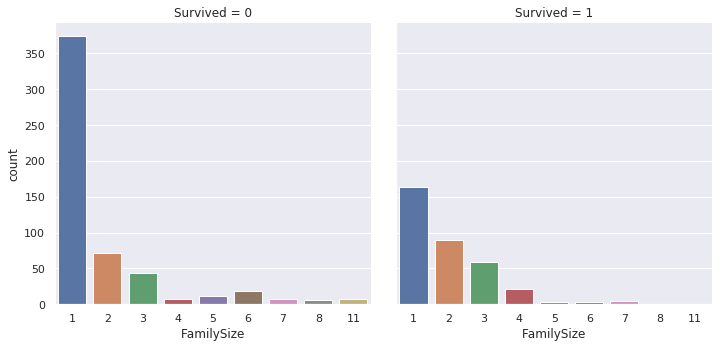

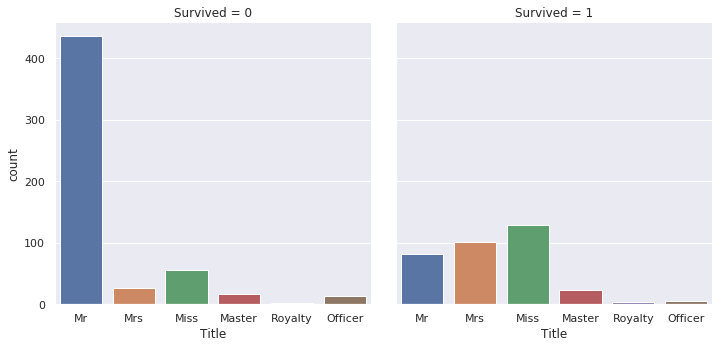

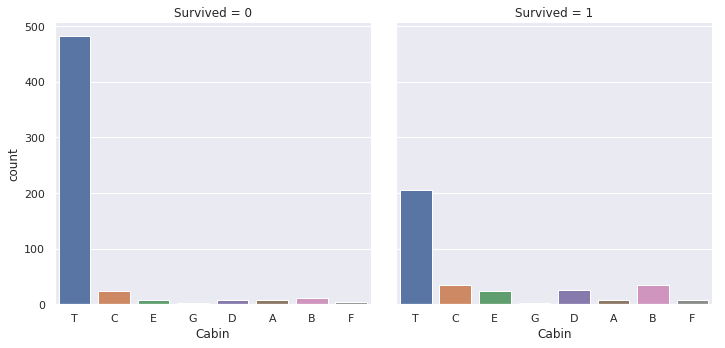

In [5]:

sns.set(style="darkgrid")
g2 = sns.FacetGrid(train_df, col='Survived',height=4,aspect=1)
bins = np.linspace(0, 60, 13)
g2.map(plt.hist, 'Age',color="steelblue", bins=bins,lw=0);

g2 = sns.FacetGrid(train_df, col='Survived',height=4,aspect=1)
bins = np.linspace(0, 60, 13)
g2.map(plt.hist, 'Fare',color="steelblue", bins=bins,lw=0);

sns.catplot(x='Sex', col='Survived', kind='count', data=train_df);
sns.catplot(x='Pclass', col='Survived', kind='count', data=train_df);
sns.catplot(x='Parch', col='Survived', kind='count', data=train_df);
sns.catplot(x='Embarked', col='Survived', kind='count', data=train_df);
sns.catplot(x='SibSp', col='Survived', kind='count', data=train_df);
sns.catplot(x='FamilySize', col='Survived', kind='count', data=train_df);
sns.catplot(x='Title', col='Survived', kind='count', data=train_df);
sns.catplot(x='Cabin', col='Survived', kind='count', data=train_df);

## Train random forest with a grid search
A grid search is computed in order to optimize the values of the parameters.

The cross validation is performed with cv Folds


In [6]:
######################################################
# Train random forest with a GridSearchCV
######################################################

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

param1={'max_depth' : [10,11,13,15],'n_estimators' : [100,500,1000]}
param = dict(     
    max_depth = [n for n in range(5, 15)],     
    min_samples_split = [n for n in range(2, 6)], 
    min_samples_leaf = [n for n in range(2, 5)],     
    n_estimators = [50,100],
    #criterion = ['gini','entropy']    
)
grid_search = GridSearchCV(RandomForestClassifier(), param, cv=7)
grid_search.fit(features, target)
print("Best parameters {}".format(grid_search.best_params_))
print("Best score {:.4f}".format(grid_search.best_score_))
result = grid_search.predict(features)
print_metrics(target,result)

Best parameters {'max_depth': 13, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 50}
Best score 0.8406
[[513  36]
 [ 66 276]]
------------------------------------------
 Accuracy    :  0.8855218855218855
 Precision   :  0.8846153846153846
 Sensitivity :  0.8070175438596491
------------------------------------------


## Train a random forest with default parameters
Overfitting ?


In [7]:
forest = RandomForestClassifier(random_state = 1)
random_forest = forest.fit(features, target)
print('Score = ',random_forest.score(features, target))
print_metrics(target,random_forest.predict(features))

Score =  0.9382716049382716
[[527  22]
 [ 33 309]]
------------------------------------------
 Accuracy    :  0.9382716049382716
 Precision   :  0.9335347432024169
 Sensitivity :  0.9035087719298246
------------------------------------------


/opt/conda/lib/python3.6/site-packages/sklearn/ensemble/forest.py:246: FutureWarning: The default value of n_estimators will change from 10 in version 0.20 to 100 in 0.22.
  "10 in version 0.20 to 100 in 0.22.", FutureWarning)


## Importances : find the feature that best separates the outcomes


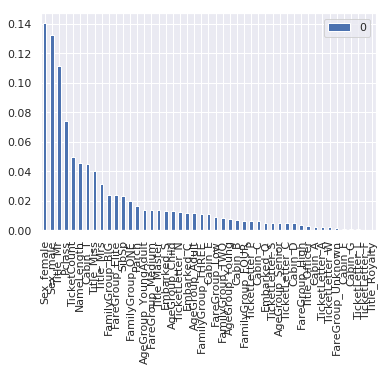

In [8]:
columns = df_f.columns
importances = list(zip(grid_search.best_estimator_.feature_importances_,columns))
importances.sort(reverse=True)
pd.DataFrame(importances, index=[x for (_,x) in importances]).plot(kind = 'bar');

## Prediction on test data 

In [9]:
y_sub= grid_search.predict(features_test)

submission = pd.DataFrame({
        "PassengerId": test_df["PassengerId"],
        "Survived": y_sub
    })
submission.to_csv('titanic.csv', index=False)
